In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

fraud_df.head()


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [2]:
fraud_df.info()
fraud_df.describe()
fraud_df.isnull().sum()
fraud_df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


np.int64(0)

In [3]:
fraud_df = fraud_df.drop_duplicates()

fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])

fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [4]:
class_counts = fraud_df["class"].value_counts()
class_percent = fraud_df["class"].value_counts(normalize=True) * 100

print(class_counts)
print(class_percent)

class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


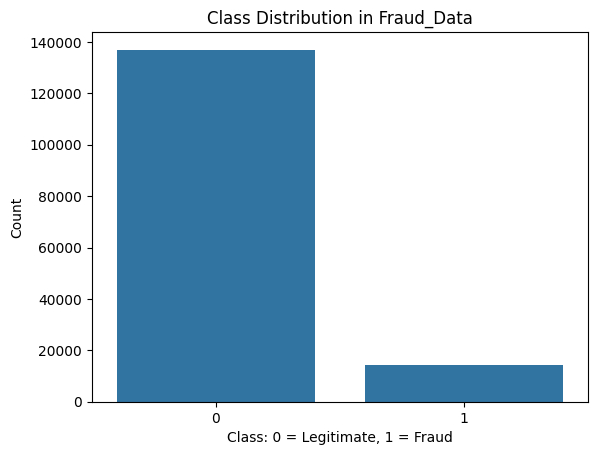

In [5]:
sns.countplot(data=fraud_df, x="class")
plt.title("Class Distribution in Fraud_Data")
plt.xlabel("Class: 0 = Legitimate, 1 = Fraud")
plt.ylabel("Count")
plt.show()

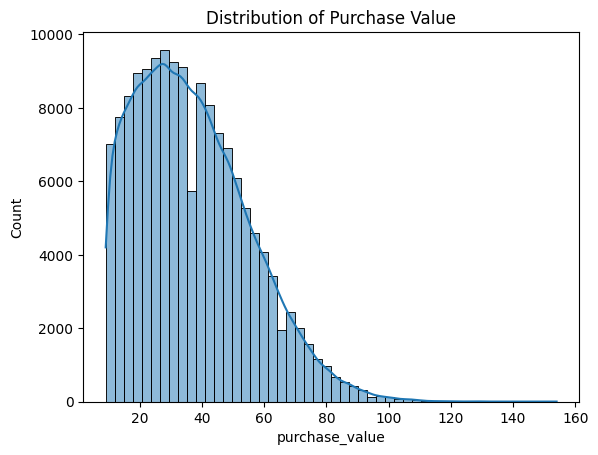

In [6]:
sns.histplot(fraud_df["purchase_value"], bins=50, kde=True)
plt.title("Distribution of Purchase Value")
plt.show()

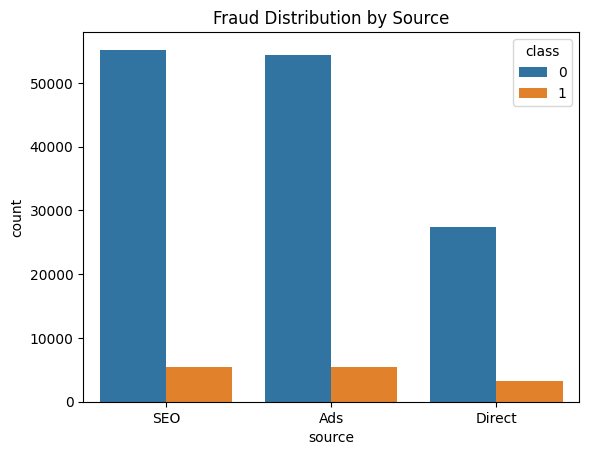

In [7]:
sns.countplot(data=fraud_df, x="source", hue="class")
plt.title("Fraud Distribution by Source")
plt.show()

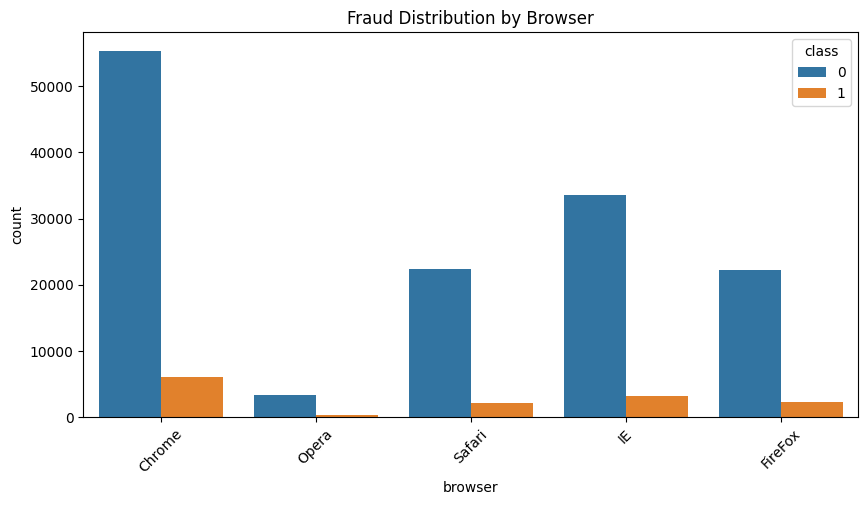

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(data=fraud_df, x="browser", hue="class")
plt.title("Fraud Distribution by Browser")
plt.xticks(rotation=45)
plt.show()

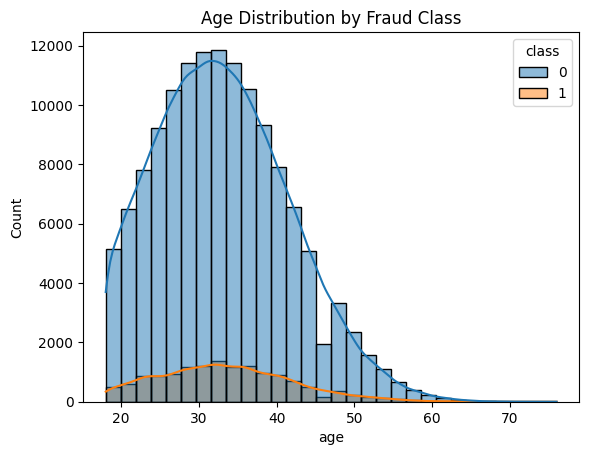

In [9]:
sns.histplot(data=fraud_df, x="age", hue="class", bins=30, kde=True)
plt.title("Age Distribution by Fraud Class")
plt.show()

In [10]:
fraud_df["ip_address"] = fraud_df["ip_address"].astype(float)
ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(float)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(float)

In [11]:
ip_df = ip_df.sort_values("lower_bound_ip_address")
fraud_df = fraud_df.sort_values("ip_address")

fraud_geo = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

fraud_geo = fraud_geo[
    fraud_geo["ip_address"] <= fraud_geo["upper_bound_ip_address"]
]

fraud_geo.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,0,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,0,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,0,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,0,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,0,16941056.0,16973823.0,Thailand


In [12]:
fraud_geo["country"].isnull().sum()

np.int64(0)

In [13]:
fraud_geo["country"] = fraud_geo["country"].fillna("Unknown")

In [14]:
country_fraud = fraud_geo.groupby("country")["class"].agg(["count", "sum", "mean"])
country_fraud = country_fraud.rename(columns={
    "count": "total_transactions",
    "sum": "fraud_transactions",
    "mean": "fraud_rate"
})

country_fraud.sort_values("fraud_transactions", ascending=False).head(10)

,total_transactions,fraud_transactions,fraud_rate
country,,,
United States,58049,5551,0.095626
China,12038,1043,0.086642
Japan,7306,715,0.097865
United Kingdom,4490,477,0.106236
Korea Republic of,4162,380,0.091302
Canada,2975,348,0.116975
France,3161,300,0.094907
Brazil,2961,270,0.091185
Germany,3646,262,0.071860


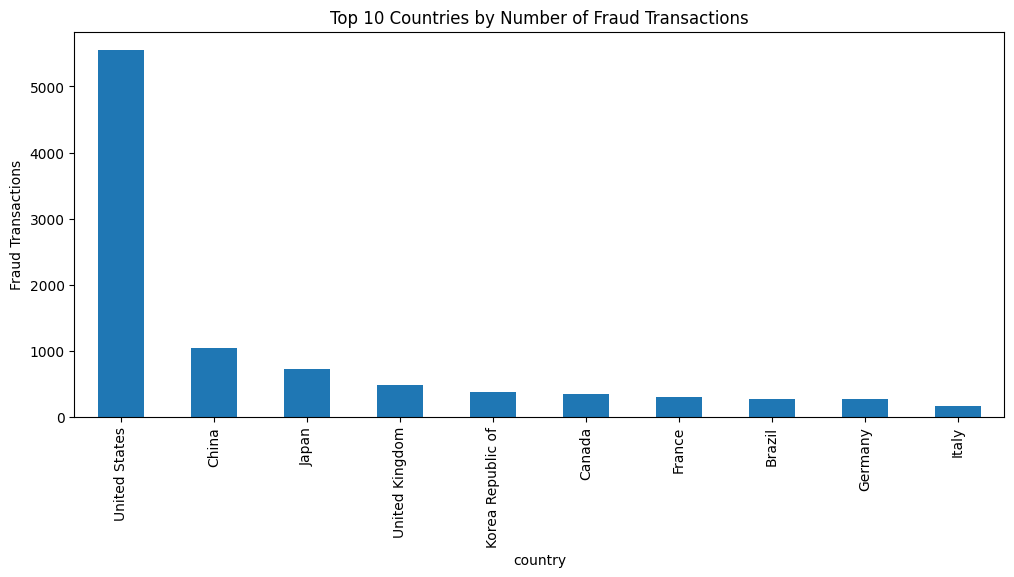

In [15]:
top_countries = country_fraud.sort_values("fraud_transactions", ascending=False).head(10)

top_countries["fraud_transactions"].plot(kind="bar", figsize=(12,5))
plt.title("Top 10 Countries by Number of Fraud Transactions")
plt.ylabel("Fraud Transactions")
plt.show()